In [188]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import date, datetime
from scipy.stats import norm as norm_rv

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


### Generate data from Black Scholes formula:

In [171]:
def Black_Scholes(S, K, T, r, σ):
    d1 = (np.log(S/K) + (r+ σ**2/2) * T ) / (σ * np.sqrt(T))
    d2 = d1 - σ * np.sqrt(T)
    call_price = S * norm_rv.cdf(d1) - K * np.exp(-r * T) * norm_rv.cdf(d2)
    return call_price

In [172]:
N = 100_000
S     = np.random.uniform(50, 150, N)       # spot price
K     = np.random.uniform(50, 150, N)       # strike price
T     = np.random.uniform(0.1, 2.0, N)      # time to expiry (years)
r     = np.random.uniform(0.01, 0.05, N)    # risk-free rate
sigma = np.random.uniform(0.1, 0.5, N)      # volatility

X = np.stack([S, K, T, r, sigma], axis=1)  # shape: (100000, 5)
Y = Black_Scholes(S, K, T, r, sigma)        # shape: (100000,)

In [159]:
x = torch.rand(5, 3)
print(x)


tensor([[0.2242, 0.4763, 0.0582],
        [0.4718, 0.0985, 0.4266],
        [0.9928, 0.4379, 0.4385],
        [0.1115, 0.6502, 0.7360],
        [0.6750, 0.5919, 0.1012]])


In [160]:
class First_NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, 1)   # no activation on output!
        )

    def forward(self, x):
        return self.net(x)

In [161]:
for name, param in First_NN().named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Layer: net.0.weight | Size: torch.Size([128, 5]) | Values : tensor([[-0.1682,  0.2440, -0.1461, -0.3145, -0.4113],
        [-0.1639, -0.0480,  0.2928, -0.1588, -0.3064]],
       grad_fn=<SliceBackward0>) 

Layer: net.0.bias | Size: torch.Size([128]) | Values : tensor([ 0.1905, -0.3283], grad_fn=<SliceBackward0>) 

Layer: net.2.weight | Size: torch.Size([128, 128]) | Values : tensor([[ 0.0641,  0.0735, -0.0536,  0.0730,  0.0230,  0.0723, -0.0620,  0.0640,
         -0.0458,  0.0789, -0.0109, -0.0692,  0.0689,  0.0260, -0.0667,  0.0596,
          0.0880,  0.0052,  0.0679,  0.0830,  0.0112,  0.0207, -0.0414, -0.0785,
          0.0518, -0.0772,  0.0448, -0.0161, -0.0037, -0.0745, -0.0344, -0.0628,
         -0.0049,  0.0525,  0.0098,  0.0730, -0.0191, -0.0484, -0.0784,  0.0468,
         -0.0185, -0.0157, -0.0265, -0.0870, -0.0811, -0.0250,  0.0433, -0.0040,
         -0.0837, -0.0498,  0.0238,  0.0343, -0.0002,  0.0154,  0.0139, -0.0860,
         -0.0474, -0.0750, -0.0756,  0.0877,  0.0229,  

In [162]:
First_NN().net[0].bias.data.numpy()

array([ 0.28883025,  0.3167882 , -0.20097654,  0.02974965,  0.09680833,
        0.23869655,  0.05490247, -0.3452091 ,  0.23219232, -0.24086773,
        0.09256528,  0.20283398,  0.3701944 ,  0.07888072,  0.18192303,
       -0.15373042,  0.29496935, -0.14846244, -0.18513402,  0.21910278,
       -0.30266207,  0.03304055,  0.16084106,  0.29666516, -0.4023991 ,
       -0.3694594 , -0.05902189, -0.0092112 , -0.2938265 ,  0.36420834,
       -0.3488975 ,  0.10508806, -0.09743181,  0.443812  , -0.35264704,
       -0.3345934 ,  0.18141492,  0.42198086, -0.31889492,  0.41346624,
       -0.09662382, -0.38917148,  0.2766226 ,  0.26385123,  0.168456  ,
       -0.3751672 ,  0.12109605, -0.4176468 ,  0.21041213,  0.21110721,
       -0.29046646, -0.16186881, -0.1630773 , -0.14668636, -0.04783868,
        0.01783196, -0.05293472,  0.06432212, -0.4420042 ,  0.23039858,
       -0.16271313,  0.3572154 , -0.4394401 , -0.03736447,  0.23117913,
       -0.22741263,  0.28818753, -0.05364639,  0.24575672,  0.35

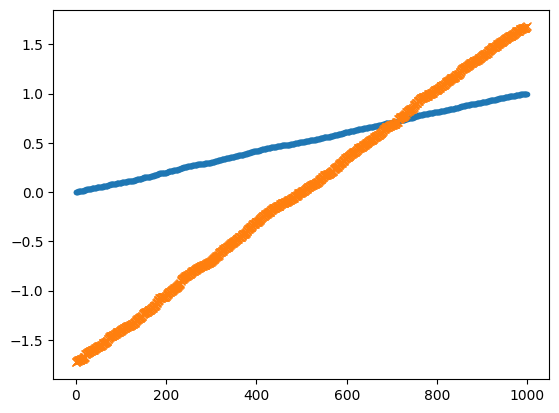

In [163]:
data = np.random.uniform(0, 1, size=1000)
data_mean = np.mean(data)
data_std = np.std(data)

plt.figure()
plt.plot(np.arange(1000, dtype=np.float32), np.sort(data), '.')
plt.plot(np.arange(1000), np.sort(data - data_mean) / data_std, 'x')
plt.show()

first try of optimization using Adam or SGD:

In [165]:
# first we create training and validation data:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2)

# scale by xs - mean /std
# scaler_x = StandardScaler()
# X_train = scaler_x.fit_transform(X_train)
# X_val   = scaler_x.transform(X_val)

# scaler_y = StandardScaler()
# Y_train = scaler_y.fit_transform(Y_train.reshape(-1, 1)).flatten()
# Y_val   = scaler_y.transform(Y_val.reshape(-1, 1)).flatten()

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32).unsqueeze(1)
Y_val_t = torch.tensor(Y_val, dtype=torch.float32).unsqueeze(1)

opt = First_NN()

In [166]:
opt.net[0].bias

Parameter containing:
tensor([ 0.2700, -0.1924, -0.2513,  0.2891,  0.2183,  0.3328,  0.2320,  0.2611,
         0.2460, -0.0821, -0.1295, -0.1100,  0.0800,  0.2804, -0.2078,  0.2628,
         0.0441, -0.0283, -0.1177,  0.4268, -0.0554, -0.3334, -0.0902,  0.3678,
        -0.4359, -0.1343,  0.2037,  0.0338,  0.2365,  0.4113,  0.3379,  0.2819,
        -0.0656, -0.3734, -0.1536, -0.3679,  0.3137, -0.0518,  0.4220,  0.1566,
        -0.4469, -0.2440,  0.2475, -0.3300,  0.1040, -0.3673, -0.1187, -0.2091,
        -0.1176,  0.0086, -0.1380, -0.2421, -0.2588,  0.0803, -0.2484, -0.0380,
        -0.4148,  0.2145,  0.1623,  0.4049, -0.3333, -0.0315, -0.0408, -0.4348,
        -0.0295, -0.3542, -0.4282,  0.2831,  0.2240, -0.1429, -0.0872,  0.2768,
         0.2455, -0.0088, -0.3312, -0.1282,  0.4223, -0.1274,  0.3227, -0.0087,
         0.1041,  0.2714, -0.1827, -0.4333,  0.2659,  0.0245, -0.3469, -0.4100,
        -0.0976, -0.0666, -0.4229,  0.3099, -0.1482, -0.3487, -0.1619, -0.4128,
         0.2086,  

In [167]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

loss_fn   = nn.HuberLoss()                                          # loss function
optimizer = torch.optim.AdamW(opt.parameters(), lr=1e-2)            # optimizer
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)  # lr decay

train_loader = DataLoader(
    TensorDataset(X_train_t, Y_train_t),
    batch_size=256,
    shuffle=True
)

In [168]:
train_losses, val_losses = [], []

for epoch in range(200):

    # -- Train --
    opt.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()           # 1. clear old gradients
        preds = opt(X_batch)            # 2. forward pass
        loss  = loss_fn(preds, y_batch) # 3. compute loss
        loss.backward()                 # 4. backprop (compute gradients)
        torch.nn.utils.clip_grad_norm_(opt.parameters(), max_norm=1.0)
        optimizer.step()                # 5. update weights
        batch_losses.append(loss.item())

    train_loss = sum(batch_losses) / len(batch_losses)

    # -- Validate --
    opt.eval()
    with torch.no_grad():
        val_loss = loss_fn(opt(X_val_t), Y_val_t).item()

    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:>3} | Train: {train_loss:.5f} | Val: {val_loss:.5f}")


Epoch   0 | Train: 3.90575 | Val: 2.35152
Epoch  20 | Train: 0.83407 | Val: 1.19285
Epoch  40 | Train: 0.45858 | Val: 1.48386
Epoch  60 | Train: 0.05789 | Val: 0.05120
Epoch  80 | Train: 0.04367 | Val: 0.02063
Epoch 100 | Train: 0.00450 | Val: 0.00627
Epoch 120 | Train: 0.00329 | Val: 0.00344
Epoch 140 | Train: 0.00272 | Val: 0.00361
Epoch 160 | Train: 0.00232 | Val: 0.00225
Epoch 180 | Train: 0.00168 | Val: 0.00180


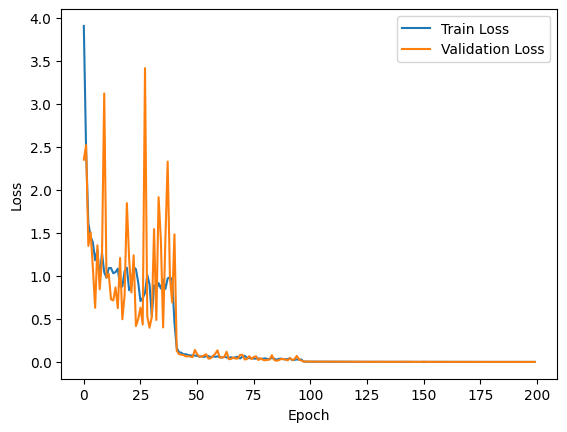

In [169]:
plt.figure()

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [153]:
opt.eval()
with torch.no_grad():
    res = opt(X_val_t)

In [154]:
res

tensor([[-0.5299],
        [ 1.0461],
        [ 2.2861],
        ...,
        [ 0.2604],
        [-0.6729],
        [ 1.4254]])

In [136]:
opt(X_val_t[0,:])

tensor([-0.1727], grad_fn=<TanhBackward0>)

In [155]:
print(Y_val_t)
print(np.mean(Y_val))

tensor([[-0.5303],
        [ 1.0463],
        [ 2.2870],
        ...,
        [ 0.2591],
        [-0.6731],
        [ 1.4263]])
0.0068091239721848485


#### Now get real data:

In [179]:
r = yf.Ticker("^IRX").history(period="1d")["Close"].iloc[-1] / 100
r_mean = np.mean(yf.Ticker("^IRX").history(period="30d")["Close"] / 100)
print(r, r_mean)

0.036050000190734864 0.03592999992699459


In [182]:
yf.Ticker("AAPL").history(period="2d")

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-03-16 00:00:00-04:00,252.110001,253.889999,249.880005,252.820007,32074200,0.0,0.0
2026-03-17 00:00:00-04:00,253.078506,255.129898,252.179993,254.229996,27556024,0.0,0.0


In [189]:
ticker = yf.Ticker("AAPL")
expiry      = ticker.options[0]
chain       = ticker.option_chain(expiry)
K           = chain.calls["strike"].iloc[0]
T           = (datetime.strptime(expiry, "%Y-%m-%d").date() - date.today()).days / 365.25

In [190]:
T

0.0027378507871321013